# Online Advertising Conversion Prediction
## Assessment 1 — Exploratory Analysis, Modelling & Prediction

This notebook predicts whether a user converts (subscribes) after seeing an online advertising
banner. We follow a four-phase plan:

1. **Exploratory Data Analysis and Preprocessing** — understand the signal, detect issues
   (missing values, skewness, imbalance, the curse of dimensionality).
2. **Building Prediction Models** — train and compare Logistic Regression (with Ridge and
   Lasso variants), kNN, LDA, QDA, and Naive Bayes.
3. **Validation and Model Selection** — 10-fold stratified CV for hyperparameter tuning,
   Bootstrap for uncertainty quantification, and principled model selection via log-loss.
4. **Generating Test Predictions** — refit on the full training set and produce predicted
   probabilities.

## Setup and Data Loading

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import log_loss, roc_auc_score, roc_curve, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 25)
SEED = 42
np.random.seed(SEED)

In [55]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
print(f"Training set : {train.shape[0]} rows, {train.shape[1]} columns")
print(f"Test set     : {test.shape[0]} rows, {test.shape[1]} columns")
train.head()

Training set : 31647 rows, 17 columns
Test set     : 13564 rows, 17 columns


,age,job,marital,education,X2,X4,X3,X1,device,day,month,time_spent,banner_views,days_elapsed_old,banner_views_old,outcome_old,y
0,36,technician,single,tertiary,0,0,0,0,unknown,17,jun,153,4,368.0,0,unknown,0
1,56,entrepreneur,married,secondary,0,196,0,0,cellular,19,nov,312,3,348.0,0,unknown,0
2,46,blue-collar,married,secondary,0,0,1,0,unknown,5,jun,83,2,370.0,0,unknown,0
3,41,management,divorced,tertiary,0,3426,0,0,cellular,1,oct,302,1,119.0,5,success,0
4,38,blue-collar,married,secondary,0,0,1,0,unknown,20,may,90,1,351.0,0,unknown,0


---
## Phase 1: Exploratory Data Analysis (EDA) and Preprocessing

The goal of this phase is to understand the signal within the data and identify issues such
as missing values, nonlinearity, skewness, class imbalance, and high dimensionality (the
curse of dimensionality) that will inform our modelling choices.

### 1.1 Variable Identification

We categorise every variable as either **quantitative** (numeric) or **qualitative**
(categorical/factor), following the data description.

In [56]:
# Quantitative variables
quantitative = ['age', 'X4', 'time_spent', 'banner_views',
                'days_elapsed_old', 'banner_views_old', 'day']

# Qualitative variables (including binary flags treated as factors)
qualitative = ['job', 'marital', 'education', 'device', 'outcome_old',
               'month', 'X1', 'X2', 'X3']

print("=== Quantitative variables ===")
print(train[quantitative].dtypes)
print(f"\nCount: {len(quantitative)} variables\n")

print("=== Qualitative variables ===")
for col in qualitative:
    levels = train[col].unique()
    print(f"  {col:20s}: {len(levels)} levels → {list(levels)}")
print(f"\nCount: {len(qualitative)} variables")

=== Quantitative variables ===
age                   int64
X4                    int64
time_spent            int64
banner_views          int64
days_elapsed_old    float64
banner_views_old      int64
day                   int64
dtype: object

Count: 7 variables

=== Qualitative variables ===
  job                 : 12 levels → ['technician', 'entrepreneur', 'blue-collar', 'management', 'admin.', 'retired', 'housemaid', 'unknown', 'services', 'student', 'unemployed', 'self-employed']
  marital             : 3 levels → ['single', 'married', 'divorced']
  education           : 4 levels → ['tertiary', 'secondary', 'primary', 'unknown']
  device              : 3 levels → ['unknown', 'cellular', 'telephone']
  outcome_old         : 4 levels → ['unknown', 'success', 'other', 'failure']
  month               : 12 levels → ['jun', 'nov', 'oct', 'may', 'jul', 'aug', 'feb', 'dec', 'sep', 'jan', 'mar', 'apr']
  X1                  : 2 levels → [np.int64(0), np.int64(1)]
  X2                  : 2 le

In [57]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31647 entries, 0 to 31646
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               31647 non-null  int64  
 1   job               31647 non-null  object 
 2   marital           31647 non-null  object 
 3   education         31647 non-null  object 
 4   X2                31647 non-null  int64  
 5   X4                31647 non-null  int64  
 6   X3                31647 non-null  int64  
 7   X1                31647 non-null  int64  
 8   device            31647 non-null  object 
 9   day               31647 non-null  int64  
 10  month             31647 non-null  object 
 11  time_spent        31647 non-null  int64  
 12  banner_views      31647 non-null  int64  
 13  days_elapsed_old  31647 non-null  float64
 14  banner_views_old  31647 non-null  int64  
 15  outcome_old       31647 non-null  object 
 16  y                 31647 non-null  int64 

In [58]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,31647.0,NaN,NaN,NaN,40.941669,10.63201,18.0,33.0,39.0,48.0,95.0
job,31647,12,blue-collar,6863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,31647,3,married,19100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,31647,4,secondary,16341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X2,31647.0,NaN,NaN,NaN,0.01937,0.137824,0.0,0.0,0.0,0.0,1.0
X4,31647.0,NaN,NaN,NaN,1357.985465,2976.874443,-6847.0,70.0,446.0,1434.0,81204.0
X3,31647.0,NaN,NaN,NaN,0.55604,0.496857,0.0,0.0,1.0,1.0,1.0
X1,31647.0,NaN,NaN,NaN,0.160458,0.367036,0.0,0.0,0.0,0.0,1.0
device,31647,3,cellular,20545,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,31647.0,NaN,NaN,NaN,15.829621,8.3232,1.0,8.0,16.0,21.0,31.0


### 1.2 Handling Missing and Special Values

There are no literal `NaN` entries in the data. Instead, the string `"unknown"` serves as a
missing-value indicator in several categorical columns. The problem description also notes
that `days_elapsed_old = -1` would indicate the user never saw the old banner.

In [59]:
# Check for literal NaN
print("=== Literal NaN counts ===")
print(train.isnull().sum())
print()

# Check for 'unknown' in categorical columns
print("=== 'unknown' counts per categorical column ===")
for c in ['job', 'education', 'device', 'outcome_old']:
    n_unk = (train[c] == 'unknown').sum()
    pct = 100 * n_unk / len(train)
    print(f"  {c:20s}: {n_unk:6d} unknown  ({pct:.1f}%)")

# Check for special value -1 in days_elapsed_old
print(f"\ndays_elapsed_old == -1 in train: {(train['days_elapsed_old'] == -1).sum()}")
print(f"days_elapsed_old == -1 in test : {(test['days_elapsed_old'] == -1).sum()}")

=== Literal NaN counts ===
age                 0
job                 0
marital             0
education           0
X2                  0
X4                  0
X3                  0
X1                  0
device              0
day                 0
month               0
time_spent          0
banner_views        0
days_elapsed_old    0
banner_views_old    0
outcome_old         0
y                   0
dtype: int64

=== 'unknown' counts per categorical column ===
  job                 :    203 unknown  (0.6%)
  education           :   1322 unknown  (4.2%)
  device              :   9065 unknown  (28.6%)
  outcome_old         :  25867 unknown  (81.7%)

days_elapsed_old == -1 in train: 0
days_elapsed_old == -1 in test : 0


In [60]:
# Cross-tabulate outcome_old with banner_views_old to understand the 'unknown' pattern
print("=== outcome_old vs (banner_views_old > 0) ===")
print(pd.crosstab(train['outcome_old'], train['banner_views_old'] > 0,
                  margins=True, colnames=['Had old banner views']))

=== outcome_old vs (banner_views_old > 0) ===
Had old banner views  False  True    All
outcome_old                             
failure                   0  3406   3406
other                     0  1326   1326
success                   0  1048   1048
unknown               25863     4  25867
All                   25863  5784  31647


**Strategy for handling missingness:**

- **`"unknown"` as its own category:** Rather than imputing, we retain `"unknown"` as a
  distinct factor level. This is appropriate because the missingness itself is informative —
  for example, `outcome_old = "unknown"` maps almost perfectly onto users who were never
  exposed to the old campaign (`banner_views_old = 0`), which is a meaningful structural
  feature, not random noise.
- **`device`:** Over 80% of values are `"unknown"`. We keep the variable but note it
  carries limited signal.
- **`days_elapsed_old`:** No `-1` values appear in either dataset, so no special handling
  is needed.
- **Numeric variables:** There are no missing numeric values, so imputation (mean, median,
  or PCA-based matrix completion) is not required here.

### 1.3 Class Imbalance Check

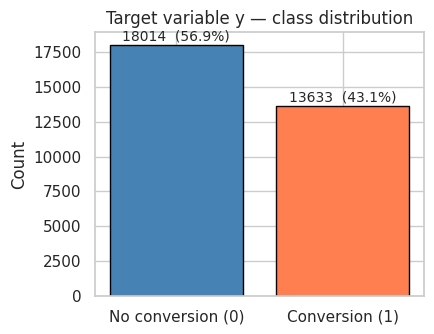

Baseline conversion rate: 0.431
Class ratio (majority / minority): 1.32


In [61]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
counts = train['y'].value_counts().sort_index()
bars = ax.bar(['No conversion (0)', 'Conversion (1)'], counts.values,
              color=['steelblue', 'coral'], edgecolor='black')
for i, v in enumerate(counts.values):
    ax.text(i, v + 300, f"{v}  ({100*v/len(train):.1f}%)", ha='center', fontsize=10)
ax.set_ylabel('Count')
ax.set_title('Target variable y — class distribution')
plt.tight_layout()
plt.show()

baseline_rate = train['y'].mean()
print(f"Baseline conversion rate: {baseline_rate:.3f}")
print(f"Class ratio (majority / minority): {counts[0] / counts[1]:.2f}")

The target split is approximately 57% non-conversion vs 43% conversion —
a **moderate** imbalance. This is not severe enough to require resampling techniques, but
we should:

1. Use **stratified** cross-validation to preserve class proportions in every fold.
2. Evaluate using **log-loss**, which is sensitive to probability calibration, rather than
   plain accuracy (which can mislead under imbalance).
3. Keep the baseline in mind: a naïve classifier predicting the majority class achieves
   only ~57% accuracy.

### 1.4 Visualising Structure

#### 1.4.1 Quantitative variables — histograms and skewness

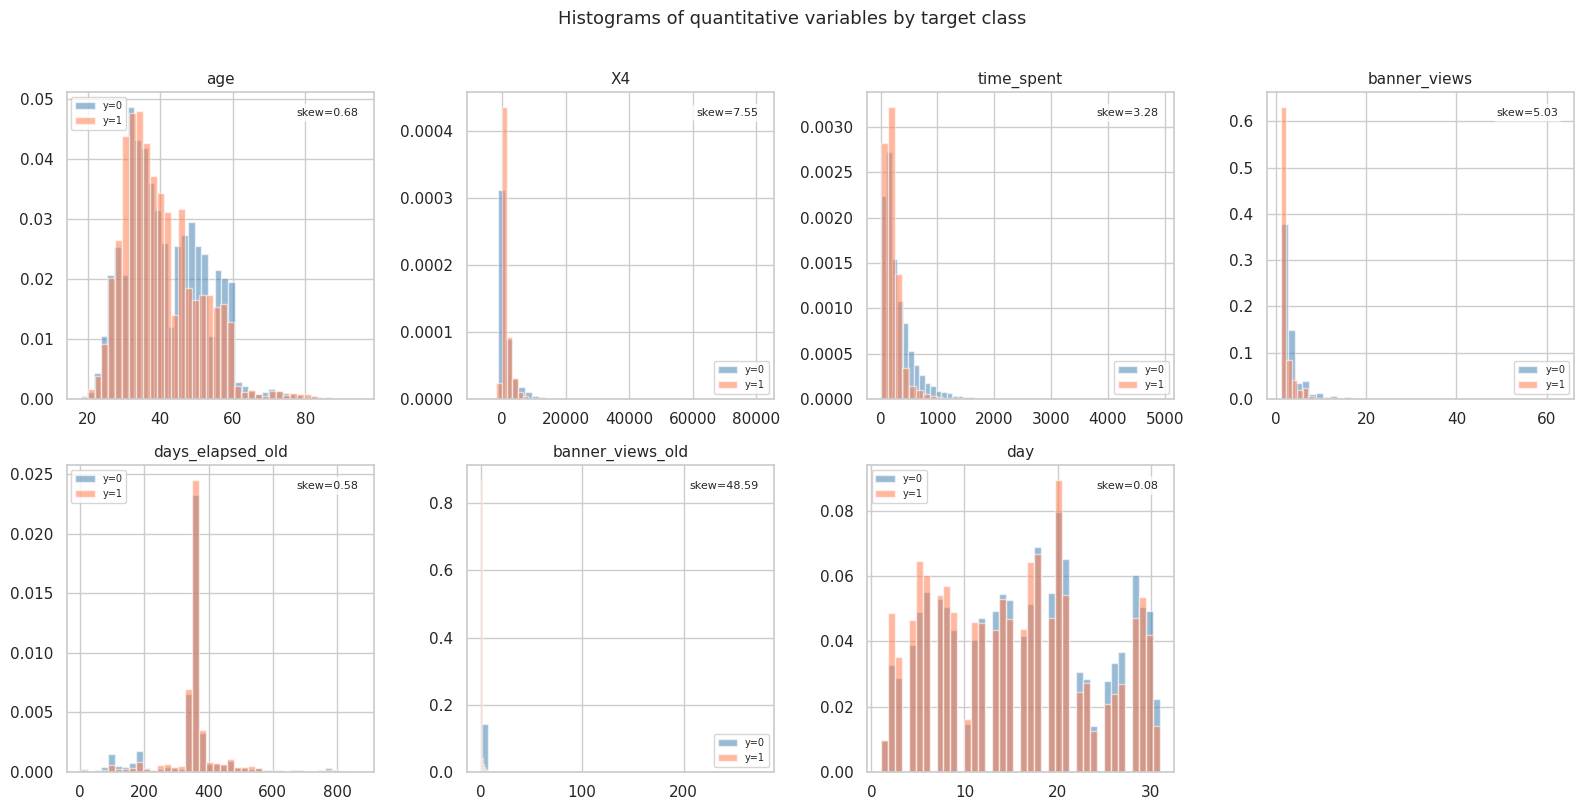

In [62]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, col in enumerate(quantitative):
    ax = axes[i]
    for yval, colour, label in [(0, 'steelblue', 'y=0'), (1, 'coral', 'y=1')]:
        subset = train.loc[train['y'] == yval, col]
        ax.hist(subset, bins=40, alpha=0.55, color=colour, label=label, density=True)
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)
    skew_val = train[col].skew()
    ax.annotate(f'skew={skew_val:.2f}', xy=(0.95, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', fc='white', alpha=0.7))

axes[-1].set_visible(False)
plt.suptitle('Histograms of quantitative variables by target class', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

**Observations on distributions:**
- **`X4`** is heavily right-skewed (skew ≈ 6+). A log-transform will help linear models.
- **`banner_views`** and **`banner_views_old`** are right-skewed.
- **`time_spent`** shows a clear shift between classes — non-converters tend to spend more
  time, suggesting that quick decisive engagement signals intent.
- **`age`** is roughly symmetric, with modest class separation.

#### 1.4.2 Scatterplot matrix (pair plot) — key quantitative variables

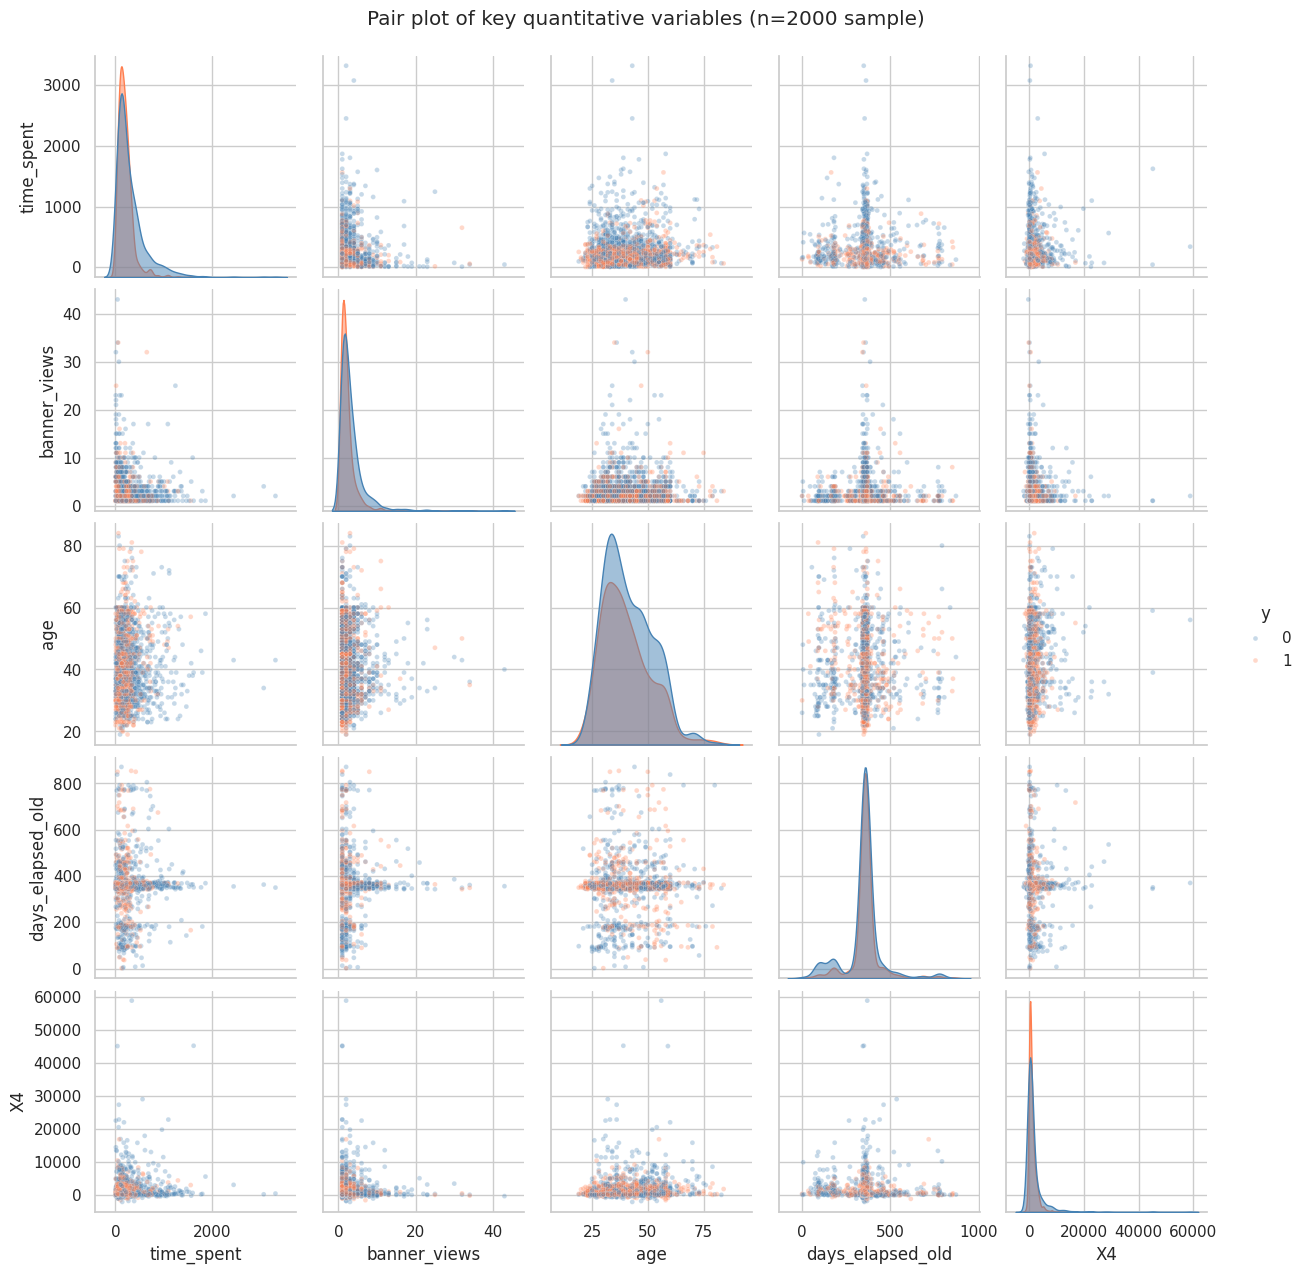

In [63]:
pair_vars = ['time_spent', 'banner_views', 'age', 'days_elapsed_old', 'X4']
sample = train[pair_vars + ['y']].sample(2000, random_state=SEED)
sample['y'] = sample['y'].astype(str)

g = sns.pairplot(sample, hue='y', vars=pair_vars, diag_kind='kde',
                 palette={'0': 'steelblue', '1': 'coral'},
                 plot_kws={'alpha': 0.3, 's': 12},
                 diag_kws={'alpha': 0.5})
g.figure.suptitle('Pair plot of key quantitative variables (n=2000 sample)', y=1.02)
plt.show()

The pair plot reveals substantial overlap between classes — no single pair of
features cleanly separates converters from non-converters. `time_spent` vs `banner_views`
shows converters concentrated at lower values of both. No dramatic nonlinear "banana-shaped"
patterns are visible, suggesting linear decision boundaries should be competitive.

#### 1.4.3 Conversion rates by categorical variables

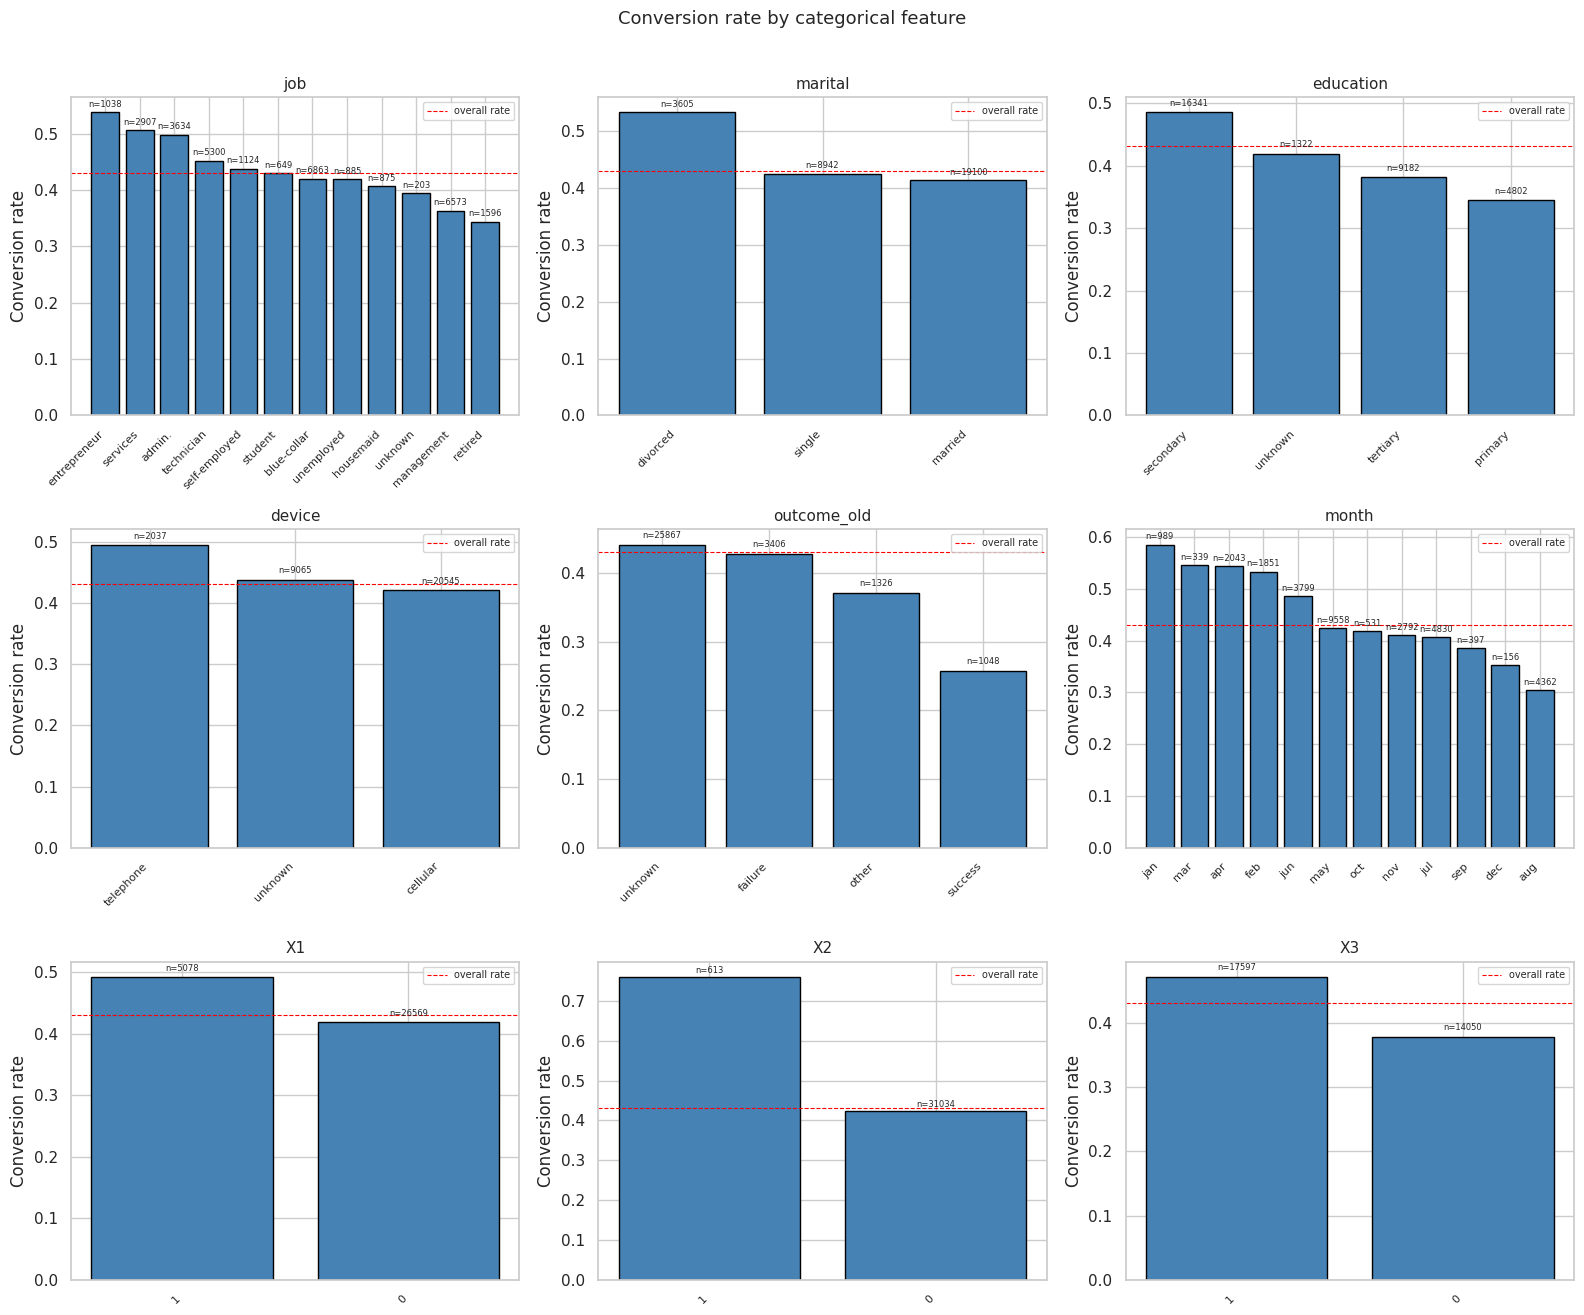

In [64]:
cat_features_plot = ['job', 'marital', 'education', 'device', 'outcome_old',
                     'month', 'X1', 'X2', 'X3']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, col in zip(axes.ravel(), cat_features_plot):
    rates = train.groupby(col)['y'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    bars = ax.bar(range(len(rates)), rates['mean'], color='steelblue', edgecolor='black')
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Conversion rate')
    ax.set_title(col, fontsize=11)
    ax.axhline(train['y'].mean(), ls='--', color='red', lw=0.8, label='overall rate')
    for i, (_, row) in enumerate(rates.iterrows()):
        ax.text(i, row['mean'] + 0.01, f"n={int(row['count'])}", ha='center', fontsize=6)
    ax.legend(fontsize=7)
plt.suptitle('Conversion rate by categorical feature', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

**Key categorical findings:**
- **`outcome_old`**: `"success"` has the *lowest* conversion rate (~26%) — these users may
  have already subscribed during the previous campaign.
- **`month`**: Strong seasonal variation; January, March, April exceed 54%.
- **`job`**: Students and retirees convert at noticeably higher rates.
- **`X1`**: Category 1 is associated with ~64% conversion vs ~40%.
- **`device`**: Limited differentiation (mostly unknown).

#### 1.4.4 Correlation structure and nonlinearity check

In [65]:
corr_with_y = train[quantitative + ['y']].corr()['y'].drop('y').sort_values()
print("Pearson correlation with y:\n")
for feat, val in corr_with_y.items():
    bar = '█' * int(abs(val) * 50)
    sign = '+' if val > 0 else '-'
    print(f"  {feat:20s}  r = {val:+.4f}  {sign} {bar}")

Pearson correlation with y:

  time_spent            r = -0.2009  - ██████████
  banner_views          r = -0.1687  - ████████
  X4                    r = -0.0778  - ███
  day                   r = -0.0639  - ███
  age                   r = -0.0531  - ██
  banner_views_old      r = -0.0224  - █
  days_elapsed_old      r = +0.0542  + ██


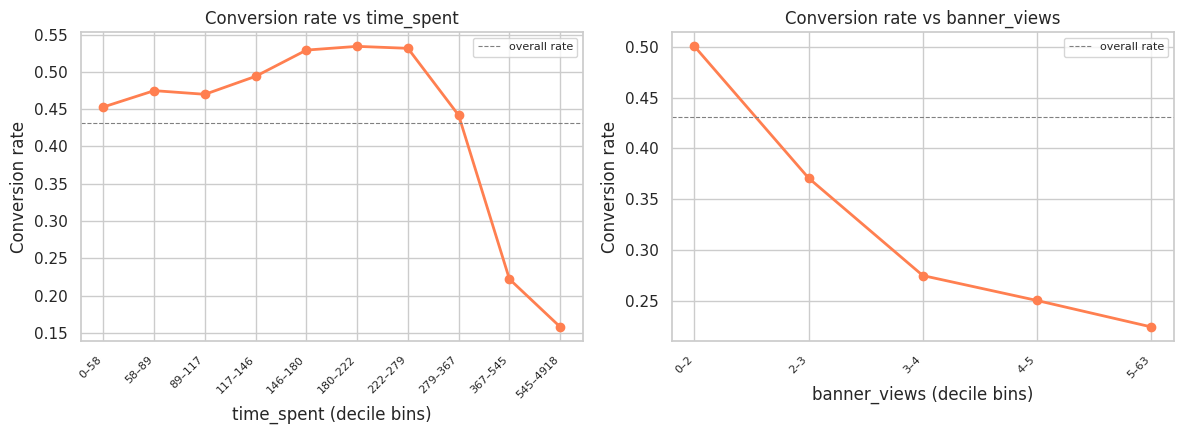

In [66]:
# Nonlinearity check: binned conversion rates for the two strongest predictors
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col in zip(axes, ['time_spent', 'banner_views']):
    tmp = train.copy()
    tmp[col + '_bin'] = pd.qcut(tmp[col], q=10, duplicates='drop')
    rates = tmp.groupby(col + '_bin')['y'].mean()
    ax.plot(range(len(rates)), rates.values, 'o-', color='coral', linewidth=2)
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels([f"{int(x.left)}–{int(x.right)}" for x in rates.index],
                        rotation=45, ha='right', fontsize=8)
    ax.set_xlabel(f'{col} (decile bins)')
    ax.set_ylabel('Conversion rate')
    ax.set_title(f'Conversion rate vs {col}')
    ax.axhline(train['y'].mean(), ls='--', color='grey', lw=0.8, label='overall rate')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Both `time_spent` and `banner_views` show roughly monotonically decreasing
relationships with conversion. This near-linear pattern is encouraging for Logistic
Regression and LDA. Some curvature at the extremes suggests that more flexible methods
(kNN, QDA) might capture additional signal there.

### 1.5 The Curse of Dimensionality

An important theoretical consideration for this dataset is the **curse of dimensionality**,
which arises when the number of predictors *p* is large relative to the structure in the data.

Our dataset has several multi-level categorical variables. When we one-hot encode them, the
effective dimensionality expands substantially. We quantify this below.

In [67]:
# Count the effective dimensionality after one-hot encoding
cat_for_counting = ['job', 'marital', 'education', 'device', 'outcome_old', 'month']
total_levels = sum(train[c].nunique() for c in cat_for_counting)
# After drop='first', the number of dummy columns is (levels - 1) per variable
total_dummies = sum(train[c].nunique() - 1 for c in cat_for_counting)

n_numeric = len(quantitative)  # 7 original numeric
n_binary  = 3  # X1, X2, X3
n_engineered = 4  # features we will add later

p_total = n_numeric + n_engineered + n_binary + total_dummies
n = len(train)

print(f"Original qualitative variables  : {len(cat_for_counting)}")
print(f"Total levels across categoricals: {total_levels}")
print(f"Dummy columns (drop-first)      : {total_dummies}")
print(f"Numeric + binary + engineered   : {n_numeric} + {n_binary} + {n_engineered} = {n_numeric + n_binary + n_engineered}")
print(f"\nTotal predictor dimension p ≈ {p_total}")
print(f"Training sample size n = {n}")
print(f"Ratio n / p ≈ {n / p_total:.0f}")

Original qualitative variables  : 6
Total levels across categoricals: 38
Dummy columns (drop-first)      : 32
Numeric + binary + engineered   : 7 + 3 + 4 = 14

Total predictor dimension p ≈ 46
Training sample size n = 31647
Ratio n / p ≈ 688


**Implications for modelling:**

The effective predictor space is around 40 dimensions after one-hot encoding. While the
ratio *n/p* is still comfortable for parametric models (~700+), this expanded dimensionality
has direct consequences for **kNN**:

- In high-dimensional spaces, the concept of "nearest neighbour" degrades. All data points
  become approximately equidistant, so the neighbourhood around a query point is no longer
  truly "local." This is the **curse of dimensionality**.
- This means kNN's bias effectively increases in high dimensions — it averages over points
  that are not genuinely close in the feature space, reducing its ability to capture local
  structure.
- Consequently, kNN may require a larger *k* to stabilise predictions, which in turn
  smooths out the very flexibility that makes kNN attractive.
- Methods like **Lasso logistic regression** handle this high-dimensional setting more
  gracefully by performing automatic variable selection — shrinking the coefficients of
  irrelevant dummy variables to exactly zero.
- **Naive Bayes** is also well-suited: by assuming predictor independence given the class,
  it effectively reduces the estimation problem to *p* univariate problems rather than one
  *p*-dimensional problem, side-stepping the curse entirely at the cost of the independence
  assumption.

We will revisit this when interpreting kNN's cross-validated performance relative to the
other models.

### 1.6 Feature Encoding and Preprocessing Pipeline

We define the preprocessing pipeline used consistently across all models:

1. **Quantitative variables** → standardised using `StandardScaler` (zero mean, unit
   variance). This is essential for kNN (distance-based) and beneficial for regularised
   Logistic Regression.
2. **Qualitative variables** → converted to **dummy variables** (one-hot encoding) with the
   first level dropped to avoid multicollinearity. `"unknown"` is retained as its own level.
3. **Binary flags** (`X1`, `X2`, `X3`) → passed through as-is.
4. **Feature engineering** → derived features motivated by the EDA.

In [68]:
def engineer_features(df):
    """Create derived features motivated by EDA."""
    df = df.copy()
    # Flag: user was exposed to old campaign
    df['old_campaign_exposed'] = (df['banner_views_old'] > 0).astype(int)
    # Flag: old campaign was a success (strong predictor from EDA)
    df['old_success'] = (df['outcome_old'] == 'success').astype(int)
    # Interaction: average time spent per banner view
    df['time_per_view'] = df['time_spent'] / df['banner_views'].clip(lower=1)
    # Log-transform X4 to reduce skewness
    df['X4_log'] = np.sign(df['X4']) * np.log1p(np.abs(df['X4']))
    return df

train_fe = engineer_features(train)
test_fe  = engineer_features(test)

print("Engineered features added: old_campaign_exposed, old_success, time_per_view, X4_log")

Engineered features added: old_campaign_exposed, old_success, time_per_view, X4_log


In [69]:
# Define column groups
numeric_features = ['age', 'X4', 'X4_log', 'time_spent', 'banner_views',
                    'days_elapsed_old', 'banner_views_old',
                    'day', 'time_per_view']
binary_features  = ['X1', 'X2', 'X3', 'old_campaign_exposed', 'old_success']
categorical_features = ['job', 'marital', 'education', 'device', 'outcome_old', 'month']

all_features = numeric_features + binary_features + categorical_features

X_train = train_fe[all_features]
y_train = train_fe['y']
X_test  = test_fe[all_features]
test_ids = test_fe['ID']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num',  StandardScaler(), numeric_features),
        ('bin',  'passthrough',    binary_features),
        ('cat',  OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'),
                 categorical_features),
    ]
)

print(f"Feature breakdown: {len(numeric_features)} numeric + {len(binary_features)} binary "
      f"+ {len(categorical_features)} categorical (one-hot encoded)")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

Feature breakdown: 9 numeric + 5 binary + 6 categorical (one-hot encoded)
X_train: (31647, 20)  |  X_test: (13564, 20)


### 1.7 PCA Visualisation

PCA was introduced in Week 4 as an unsupervised tool to find directions of maximal variance.
We apply it here to (a) check whether the data admits a low-dimensional structure and
(b) visualise class separation in a reduced space.

Processed feature matrix shape: (31647, 46)


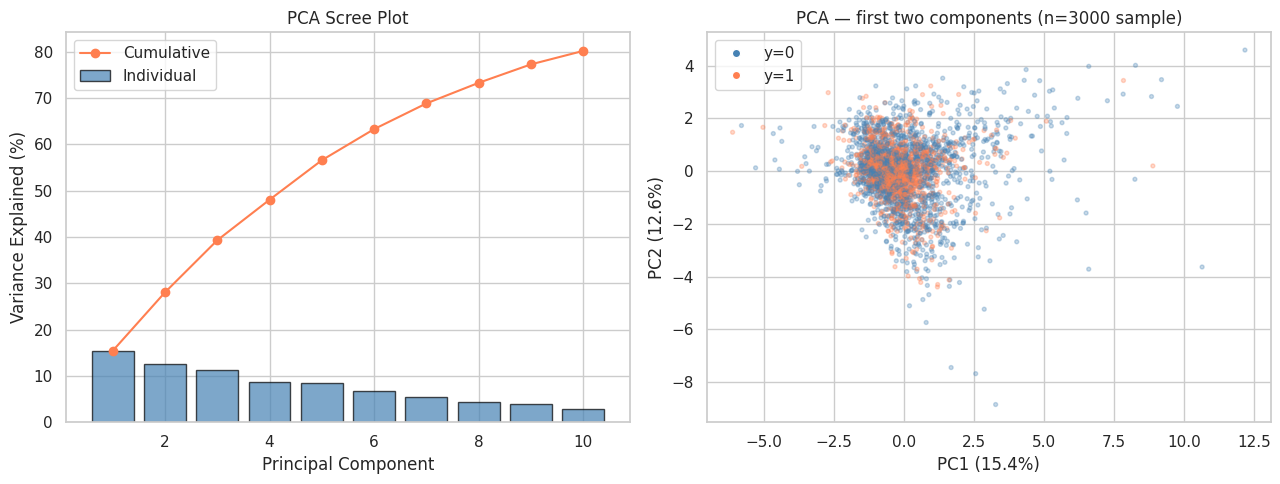

Cumulative variance explained by 5 PCs: 56.6%
Cumulative variance explained by 10 PCs: 80.2%


In [70]:
X_train_processed = preprocessor.fit_transform(X_train)
print(f"Processed feature matrix shape: {X_train_processed.shape}")

pca = PCA(n_components=10, random_state=SEED)
X_pca = pca.fit_transform(X_train_processed)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
ax = axes[0]
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
ax.bar(range(1, 11), pca.explained_variance_ratio_ * 100, color='steelblue',
       edgecolor='black', alpha=0.7, label='Individual')
ax.plot(range(1, 11), cum_var, 'o-', color='coral', label='Cumulative')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('PCA Scree Plot')
ax.legend()

# 2D scatter on first two PCs
ax = axes[1]
colours = y_train.map({0: 'steelblue', 1: 'coral'})
sample_idx = np.random.choice(len(X_pca), 3000, replace=False)
ax.scatter(X_pca[sample_idx, 0], X_pca[sample_idx, 1],
           c=colours.iloc[sample_idx], alpha=0.3, s=8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — first two components (n=3000 sample)')
from matplotlib.lines import Line2D
legend_elems = [Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='y=0'),
                Line2D([0],[0], marker='o', color='w', markerfacecolor='coral', label='y=1')]
ax.legend(handles=legend_elems)

plt.tight_layout()
plt.show()

print(f"Cumulative variance explained by 5 PCs: {cum_var[4]:.1f}%")
print(f"Cumulative variance explained by 10 PCs: {cum_var[9]:.1f}%")

The PCA scatter confirms that the two classes overlap substantially — there is
no clean linear separator in this low-dimensional projection. Variance is spread across
many components, consistent with the high effective dimensionality discussed in Section 1.5.

### 1.8 EDA Summary

| Finding | Implication for modelling |
|---|---|
| Moderate class imbalance (43% positive) | Use stratified CV; log-loss as evaluation metric |
| `"unknown"` encodes structural missingness | Retain as its own category, do not impute |
| No literal NaN in numeric columns | No numeric imputation needed |
| `outcome_old = "success"` → lowest conversion | Strong predictor; include as feature |
| `time_spent`, `banner_views` negatively correlated with y | Key numeric predictors; near-linear relationship |
| `X4` heavily skewed | Apply log-transform |
| `month`, `X1` show large group-level differences | Important categorical predictors |
| `device` mostly unknown | Low signal; include but expect low importance |
| High effective dimensionality (~40 after one-hot) | Curse of dimensionality affects kNN; favours Lasso for variable selection and Naive Bayes for variance reduction |
| Pair plot / PCA show overlap, no dramatic nonlinearity | Linear models (LR, LDA) should be competitive |

---
## Phase 2: Building Prediction Models

We train six models from the methods covered in the course, keeping the **bias-variance
trade-off** in mind. Each model is wrapped in a `Pipeline` with consistent preprocessing.

**Discriminative models:**
1. **Logistic Regression (Ridge / L2)** — directly estimates P(y=1|X) with L2
   regularisation. Robust baseline; does not require normality assumptions.
2. **Logistic Regression (Lasso / L1)** — same as above but with L1 penalty, which performs
   **automatic variable selection** by shrinking irrelevant coefficients to exactly zero.
   Particularly valuable for this dataset because of the unnamed variables (X1–X4) and the
   many dummy variables from one-hot encoding.
3. **k-Nearest Neighbours (kNN)** — a non-parametric method that classifies based on
   majority vote of the *k* closest training points. Requires standardised features.

**Generative models:**
4. **Linear Discriminant Analysis (LDA)** — assumes each class has a multivariate Gaussian
   distribution with a **shared** covariance matrix (linear boundary). Low variance, high
   bias.
5. **Quadratic Discriminant Analysis (QDA)** — like LDA but allows each class its **own**
   covariance matrix (quadratic boundary). More flexible, but estimates more parameters.
6. **Naive Bayes** — assumes predictors are **independent** given the class. This "naive"
   assumption effectively reduces a *p*-dimensional estimation problem to *p* univariate
   problems, dramatically reducing variance. This makes it well-suited to the high
   dimensionality after one-hot encoding, at the cost of potentially increased bias if
   predictors are correlated.

In [71]:
# 10-fold stratified cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

# Define models with reasonable starting hyperparameters
models = {
    'Logistic Regression (Ridge, C=1)': Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(penalty='l2', C=1.0, max_iter=2000,
                                    solver='lbfgs', random_state=SEED))
    ]),
    'Logistic Regression (Lasso, C=1)': Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(penalty='l1', C=1.0, max_iter=2000,
                                    solver='saga', random_state=SEED))
    ]),
    'kNN (k=30)': Pipeline([
        ('pre', preprocessor),
        ('clf', KNeighborsClassifier(n_neighbors=30))
    ]),
    'LDA': Pipeline([
        ('pre', preprocessor),
        ('clf', LinearDiscriminantAnalysis())
    ]),
    'QDA': Pipeline([
        ('pre', preprocessor),
        ('clf', QuadraticDiscriminantAnalysis(reg_param=0.5))
    ]),
    'Naive Bayes': Pipeline([
        ('pre', preprocessor),
        ('clf', GaussianNB())
    ]),
}

# Evaluate all models
print(f"{'Model':<40s}  {'Log-Loss':>18s}  {'ROC-AUC':>18s}")
print('-' * 80)

results = {}
for name, pipe in models.items():
    ll_scores  = cross_val_score(pipe, X_train, y_train, cv=cv,
                                  scoring='neg_log_loss', n_jobs=-1)
    auc_scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                                  scoring='roc_auc', n_jobs=-1)
    results[name] = {
        'log_loss_mean': -ll_scores.mean(),
        'log_loss_std':   ll_scores.std(),
        'auc_mean':       auc_scores.mean(),
        'auc_std':        auc_scores.std(),
    }
    print(f"{name:<40s}  {-ll_scores.mean():.4f} ± {ll_scores.std():.4f}   "
          f"{auc_scores.mean():.4f} ± {auc_scores.std():.4f}")

Model                                               Log-Loss             ROC-AUC
--------------------------------------------------------------------------------
Logistic Regression (Ridge, C=1)          0.5834 ± 0.0085   0.7596 ± 0.0100
Logistic Regression (Lasso, C=1)          0.5834 ± 0.0085   0.7597 ± 0.0100
kNN (k=30)                                0.5278 ± 0.0089   0.8181 ± 0.0085
LDA                                       0.5872 ± 0.0071   0.7524 ± 0.0102
QDA                                       0.7077 ± 0.0338   0.7618 ± 0.0107
Naive Bayes                               1.8126 ± 0.1246   0.6948 ± 0.0110


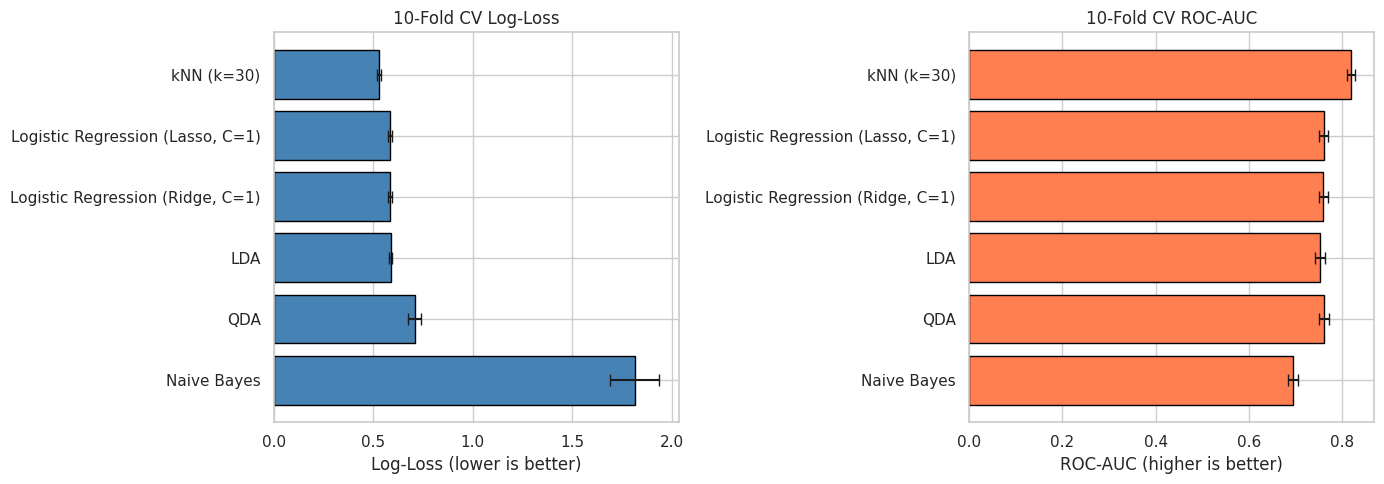

In [72]:
# Visualise cross-validation results
res_df = pd.DataFrame(results).T.sort_values('log_loss_mean')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.barh(res_df.index, res_df['log_loss_mean'], xerr=res_df['log_loss_std'],
        color='steelblue', edgecolor='black', capsize=4)
ax.set_xlabel('Log-Loss (lower is better)')
ax.set_title('10-Fold CV Log-Loss')
ax.invert_yaxis()

ax = axes[1]
ax.barh(res_df.index, res_df['auc_mean'], xerr=res_df['auc_std'],
        color='coral', edgecolor='black', capsize=4)
ax.set_xlabel('ROC-AUC (higher is better)')
ax.set_title('10-Fold CV ROC-AUC')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

**Initial comparison:**

- **Ridge and Lasso Logistic Regression** perform similarly at the default C=1 — both are
  strong baselines. We will tune *C* for each separately.
- **LDA** performs comparably to Logistic Regression, as expected when both estimate
  similar linear boundaries.
- **Naive Bayes** has decent AUC but potentially higher log-loss. Its independence
  assumption reduces variance (helpful in ~40 dimensions) but introduces bias when
  predictors are correlated (e.g., `time_spent` and `banner_views`).
- **QDA** may struggle with the high-dimensional one-hot encoded features, needing to
  estimate separate covariance matrices per class.
- **kNN** has not yet been tuned — its performance depends heavily on *k*, and the curse
  of dimensionality (Section 1.5) means it faces structural headwinds in this feature space.

---
## Phase 3: Validation and Model Selection

We use **10-fold stratified cross-validation** to tune hyperparameters and select the final
model. The primary metric is **log-loss** (the competition evaluation metric). We then use
the **Bootstrap** to quantify uncertainty around our performance estimates and assess whether
differences between models are statistically meaningful.

### 3.1 Tuning Logistic Regression — Ridge (L2 penalty)

The parameter *C* is the **inverse of the regularisation strength** λ: smaller *C* means
stronger regularisation (higher bias, lower variance). Ridge regression (L2 penalty) shrinks
all coefficients towards zero but does not set any exactly to zero.

In [73]:
C_values = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
ridge_results = []

for C in C_values:
    pipe = Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(penalty='l2', C=C, max_iter=2000,
                                    solver='lbfgs', random_state=SEED))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring='neg_log_loss', n_jobs=-1)
    ridge_results.append({'C': C, 'log_loss': -scores.mean(), 'std': scores.std()})
    print(f"  Ridge C = {C:8.3f}  →  log-loss = {-scores.mean():.5f} ± {scores.std():.5f}")

ridge_df = pd.DataFrame(ridge_results)
best_C_ridge = ridge_df.loc[ridge_df['log_loss'].idxmin(), 'C']
best_ridge_ll = ridge_df['log_loss'].min()
print(f"\n✓ Best Ridge C = {best_C_ridge}  (log-loss = {best_ridge_ll:.5f})")

  Ridge C =    0.001  →  log-loss = 0.60587 ± 0.00589
  Ridge C =    0.010  →  log-loss = 0.58692 ± 0.00797
  Ridge C =    0.050  →  log-loss = 0.58370 ± 0.00835
  Ridge C =    0.100  →  log-loss = 0.58345 ± 0.00842
  Ridge C =    0.500  →  log-loss = 0.58339 ± 0.00849
  Ridge C =    1.000  →  log-loss = 0.58340 ± 0.00851
  Ridge C =    5.000  →  log-loss = 0.58340 ± 0.00851
  Ridge C =   10.000  →  log-loss = 0.58341 ± 0.00850
  Ridge C =   50.000  →  log-loss = 0.58340 ± 0.00850

✓ Best Ridge C = 0.5  (log-loss = 0.58339)


### 3.2 Tuning Logistic Regression — Lasso (L1 penalty)

Lasso (L1 penalty) is specifically valuable for this dataset: it performs **automatic
variable selection** by forcing the coefficients of noise variables to exactly zero. This is
particularly relevant given the unnamed variables (X1–X4) and the many dummy columns from
one-hot encoding — Lasso can identify which are truly predictive and which are noise.

In [74]:
lasso_results = []

for C in C_values:
    pipe = Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(penalty='l1', C=C, max_iter=2000,
                                    solver='saga', random_state=SEED))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring='neg_log_loss', n_jobs=-1)
    lasso_results.append({'C': C, 'log_loss': -scores.mean(), 'std': scores.std()})
    print(f"  Lasso C = {C:8.3f}  →  log-loss = {-scores.mean():.5f} ± {scores.std():.5f}")

lasso_df = pd.DataFrame(lasso_results)
best_C_lasso = lasso_df.loc[lasso_df['log_loss'].idxmin(), 'C']
best_lasso_ll = lasso_df['log_loss'].min()
print(f"\n✓ Best Lasso C = {best_C_lasso}  (log-loss = {best_lasso_ll:.5f})")

  Lasso C =    0.001  →  log-loss = 0.64560 ± 0.00330
  Lasso C =    0.010  →  log-loss = 0.59573 ± 0.00754
  Lasso C =    0.050  →  log-loss = 0.58415 ± 0.00841
  Lasso C =    0.100  →  log-loss = 0.58357 ± 0.00846
  Lasso C =    0.500  →  log-loss = 0.58335 ± 0.00852
  Lasso C =    1.000  →  log-loss = 0.58337 ± 0.00852
  Lasso C =    5.000  →  log-loss = 0.58339 ± 0.00852
  Lasso C =   10.000  →  log-loss = 0.58340 ± 0.00852
  Lasso C =   50.000  →  log-loss = 0.58340 ± 0.00852

✓ Best Lasso C = 0.5  (log-loss = 0.58335)


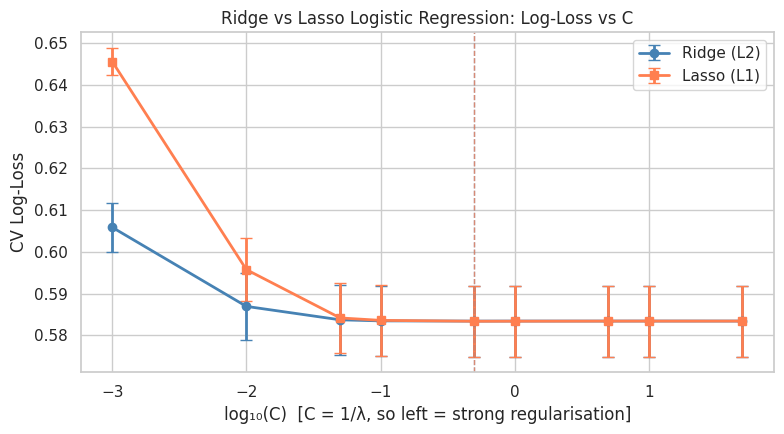

In [75]:
# Compare Ridge vs Lasso tuning curves
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(np.log10(ridge_df['C']), ridge_df['log_loss'], yerr=ridge_df['std'],
            fmt='o-', color='steelblue', capsize=4, linewidth=2, markersize=6, label='Ridge (L2)')
ax.errorbar(np.log10(lasso_df['C']), lasso_df['log_loss'], yerr=lasso_df['std'],
            fmt='s-', color='coral', capsize=4, linewidth=2, markersize=6, label='Lasso (L1)')
ax.axvline(np.log10(best_C_ridge), ls='--', color='steelblue', lw=1, alpha=0.7)
ax.axvline(np.log10(best_C_lasso), ls='--', color='coral', lw=1, alpha=0.7)
ax.set_xlabel('log₁₀(C)  [C = 1/λ, so left = strong regularisation]')
ax.set_ylabel('CV Log-Loss')
ax.set_title('Ridge vs Lasso Logistic Regression: Log-Loss vs C')
ax.legend()
plt.tight_layout()
plt.show()

Both Ridge and Lasso are fairly robust across a wide range of *C* values,
indicating the model is not overly sensitive to regularisation. If their best log-losses
are similar, we may prefer Lasso for its variable selection property — yielding a more
interpretable model.

#### 3.2.1 Lasso variable selection — which coefficients survive?

One of Lasso's key advantages is that it produces a **sparse** model. We examine which
coefficients are shrunk to exactly zero at the best *C*.

In [76]:
# Fit Lasso at best C on full training set to inspect coefficients
lasso_inspect = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(penalty='l1', C=best_C_lasso, max_iter=2000,
                                solver='saga', random_state=SEED))
])
lasso_inspect.fit(X_train, y_train)

# Get feature names
ohe = lasso_inspect.named_steps['pre'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(categorical_features).tolist()
feature_names = numeric_features + binary_features + cat_names

lasso_coef = pd.Series(lasso_inspect.named_steps['clf'].coef_[0], index=feature_names)
n_zero = (lasso_coef == 0).sum()
n_nonzero = (lasso_coef != 0).sum()

print(f"Total features         : {len(lasso_coef)}")
print(f"Non-zero coefficients  : {n_nonzero}")
print(f"Zeroed-out by Lasso    : {n_zero}")
print(f"\n=== Features removed by Lasso (coefficient = 0) ===")
print(lasso_coef[lasso_coef == 0].index.tolist())

print(f"\n=== Surviving features (sorted by |coefficient|) ===")
surviving = lasso_coef[lasso_coef != 0].reindex(
    lasso_coef[lasso_coef != 0].abs().sort_values(ascending=False).index)
for feat, val in surviving.items():
    print(f"  {feat:35s}  {val:+.4f}")

Total features         : 46
Non-zero coefficients  : 44
Zeroed-out by Lasso    : 2

=== Features removed by Lasso (coefficient = 0) ===
['job_housemaid', 'job_unknown']

=== Surviving features (sorted by |coefficient|) ===
  X2                                   +2.2508
  time_spent                           -0.8335
  month_aug                            -0.7332
  month_nov                            -0.6929
  marital_single                       -0.6721
  education_secondary                  +0.6016
  banner_views                         -0.5986
  month_may                            -0.5903
  month_jul                            -0.5728
  marital_married                      -0.5635
  device_telephone                     +0.5533
  X3                                   +0.4810
  X4_log                               +0.4346
  education_unknown                    +0.4344
  job_entrepreneur                     +0.4149
  X4                                   -0.4090
  old_campaign_exposed   

This demonstrates Lasso's variable selection in action: it identifies which of
the many dummy variables and engineered features are genuinely predictive and discards the
rest. This is especially useful given the unnamed variables X1–X4, where Lasso can
empirically determine their relevance without relying on domain knowledge.

### 3.3 Tuning kNN — number of neighbours *k*

The choice of *k* directly controls the bias-variance trade-off:
- Small *k* → low bias, high variance (overfitting risk).
- Large *k* → high bias, low variance (underfitting risk).

Given the **curse of dimensionality** discussion in Section 1.5, we expect kNN to need a
relatively large *k* in this ~40-dimensional feature space, because the neighbourhoods are
no longer truly "local" — all points are approximately equidistant in high dimensions.

In [77]:
k_values = [3, 5, 7, 10, 15, 20, 30, 50, 75, 100, 150]
knn_results = []

for k in k_values:
    pipe = Pipeline([
        ('pre', preprocessor),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring='neg_log_loss', n_jobs=-1)
    knn_results.append({'k': k, 'log_loss': -scores.mean(), 'std': scores.std()})
    print(f"  k = {k:4d}  →  log-loss = {-scores.mean():.5f} ± {scores.std():.5f}")

knn_df = pd.DataFrame(knn_results)
best_k = int(knn_df.loc[knn_df['log_loss'].idxmin(), 'k'])
best_knn_ll = knn_df['log_loss'].min()
print(f"\n✓ Best k = {best_k}  (log-loss = {best_knn_ll:.5f})")

  k =    3  →  log-loss = 3.60888 ± 0.15747
  k =    5  →  log-loss = 1.82442 ± 0.13688
  k =    7  →  log-loss = 1.20173 ± 0.07413
  k =   10  →  log-loss = 0.80063 ± 0.05235
  k =   15  →  log-loss = 0.63132 ± 0.03111
  k =   20  →  log-loss = 0.56906 ± 0.02032
  k =   30  →  log-loss = 0.52776 ± 0.00888
  k =   50  →  log-loss = 0.52092 ± 0.00874
  k =   75  →  log-loss = 0.52251 ± 0.00685
  k =  100  →  log-loss = 0.52560 ± 0.00682
  k =  150  →  log-loss = 0.53212 ± 0.00626

✓ Best k = 50  (log-loss = 0.52092)


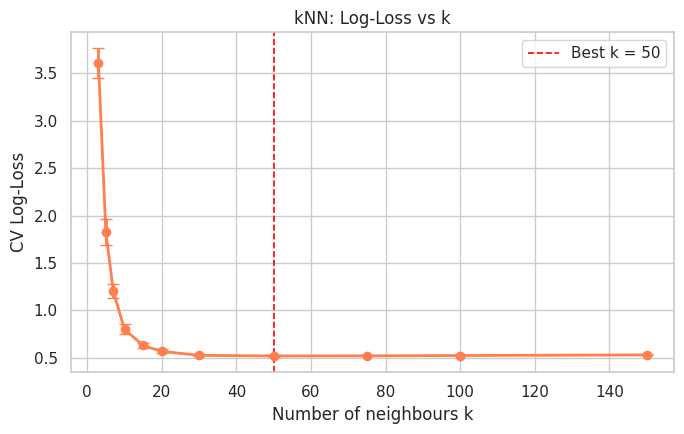

In [78]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(knn_df['k'], knn_df['log_loss'], yerr=knn_df['std'],
            fmt='o-', color='coral', capsize=4, linewidth=2, markersize=6)
ax.set_xlabel('Number of neighbours k')
ax.set_ylabel('CV Log-Loss')
ax.set_title('kNN: Log-Loss vs k')
ax.axvline(best_k, ls='--', color='red', lw=1.2, label=f'Best k = {best_k}')
ax.legend()
plt.tight_layout()
plt.show()

As anticipated from the curse of dimensionality analysis, the optimal *k* is
relatively large. Very small *k* overfits (high variance from noisy local estimates),
while very large *k* underfits. The fact that kNN needs a large *k* confirms that
neighbourhoods in this ~40-dimensional space are not truly "local" — the model must average
over many points to get stable estimates, which smooths out the very flexibility that
makes kNN attractive in lower dimensions.

Note also that kNN's probability estimates (proportion of neighbours in each class) are
inherently coarse, which directly impacts log-loss — a metric that heavily penalises
poorly calibrated probabilities.

### 3.4 LDA vs QDA — shared vs separate covariance

LDA assumes a **shared** covariance matrix across classes (linear boundary), while QDA
allows each class its **own** covariance matrix (quadratic boundary). QDA is more flexible
but estimates many more parameters — with ~40 features, each class-specific covariance
matrix has ~40×41/2 = 820 unique entries.

QDA can suffer from near-singular covariance estimates with one-hot encoded features, so
we apply a regularisation parameter `reg_param` to stabilise the estimates.

In [79]:
# LDA (no hyperparameters to tune)
lda_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', LinearDiscriminantAnalysis())
])
lda_ll = cross_val_score(lda_pipe, X_train, y_train, cv=cv,
                          scoring='neg_log_loss', n_jobs=-1)
print(f"LDA              log-loss = {-lda_ll.mean():.5f} ± {lda_ll.std():.5f}")

# QDA with regularisation search
qda_regs = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
qda_results = []

for reg in qda_regs:
    pipe = Pipeline([
        ('pre', preprocessor),
        ('clf', QuadraticDiscriminantAnalysis(reg_param=reg))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring='neg_log_loss', n_jobs=-1)
    qda_results.append({'reg_param': reg, 'log_loss': -scores.mean(), 'std': scores.std()})
    print(f"  QDA (reg={reg:.1f})  log-loss = {-scores.mean():.5f} ± {scores.std():.5f}")

qda_df = pd.DataFrame(qda_results)
best_reg = qda_df.loc[qda_df['log_loss'].idxmin(), 'reg_param']
best_qda_ll = qda_df['log_loss'].min()
print(f"\n✓ Best QDA reg_param = {best_reg}  (log-loss = {best_qda_ll:.5f})")
print(f"  LDA log-loss = {-lda_ll.mean():.5f}")

if -lda_ll.mean() < best_qda_ll:
    print("  → LDA outperforms QDA. The extra flexibility of QDA is not justified here.")
else:
    print("  → QDA outperforms LDA. The quadratic boundary captures additional structure.")

LDA              log-loss = 0.58721 ± 0.00708
  QDA (reg=0.1)  log-loss = 0.90566 ± 0.07054
  QDA (reg=0.2)  log-loss = 0.83639 ± 0.05786
  QDA (reg=0.3)  log-loss = 0.78396 ± 0.04793
  QDA (reg=0.5)  log-loss = 0.70768 ± 0.03383
  QDA (reg=0.7)  log-loss = 0.65746 ± 0.02369
  QDA (reg=0.9)  log-loss = 0.62775 ± 0.01175

✓ Best QDA reg_param = 0.9  (log-loss = 0.62775)
  LDA log-loss = 0.58721
  → LDA outperforms QDA. The extra flexibility of QDA is not justified here.


### 3.5 Naive Bayes

Naive Bayes is a **generative** classifier that assumes predictors are conditionally
independent given the class. This assumption effectively reduces a *p*-dimensional density
estimation problem to *p* separate univariate problems, which dramatically reduces variance
— particularly beneficial in our ~40-dimensional feature space.

The trade-off is increased bias: if predictors are correlated (e.g., `time_spent` and
`banner_views` are both measures of engagement), the independence assumption is violated
and the model may produce poorly calibrated probabilities. We evaluate this using log-loss.

In [80]:
# Naive Bayes with variance smoothing search
var_smooth_values = [1e-12, 1e-9, 1e-6, 1e-3, 1e-1, 1.0]
nb_results = []

for vs in var_smooth_values:
    pipe = Pipeline([
        ('pre', preprocessor),
        ('clf', GaussianNB(var_smoothing=vs))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring='neg_log_loss', n_jobs=-1)
    nb_results.append({'var_smoothing': vs, 'log_loss': -scores.mean(), 'std': scores.std()})
    print(f"  var_smoothing = {vs:.0e}  →  log-loss = {-scores.mean():.5f} ± {scores.std():.5f}")

nb_df = pd.DataFrame(nb_results)
best_vs = nb_df.loc[nb_df['log_loss'].idxmin(), 'var_smoothing']
best_nb_ll = nb_df['log_loss'].min()
print(f"\n✓ Best var_smoothing = {best_vs:.0e}  (log-loss = {best_nb_ll:.5f})")

  var_smoothing = 1e-12  →  log-loss = 1.81264 ± 0.12460
  var_smoothing = 1e-09  →  log-loss = 1.81264 ± 0.12460
  var_smoothing = 1e-06  →  log-loss = 1.81257 ± 0.12460
  var_smoothing = 1e-03  →  log-loss = 1.74223 ± 0.12080
  var_smoothing = 1e-01  →  log-loss = 1.02350 ± 0.07148
  var_smoothing = 1e+00  →  log-loss = 0.75771 ± 0.02625

✓ Best var_smoothing = 1e+00  (log-loss = 0.75771)


### 3.6 Head-to-head comparison of all tuned models

In [85]:
# ── 3.6 Head-to-head comparison of all tuned models ──────────────────────────
tuned_models = {
    f'Ridge LR (C={best_C_ridge})': Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(
            penalty='l2', C=best_C_ridge,
            max_iter=2000, solver='lbfgs',
            random_state=SEED
        ))
    ]),
    f'Lasso LR (C={best_C_lasso})': Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(
        penalty='l1', C=best_C_lasso,
        max_iter=1000,
        solver='liblinear',  # ← replaces saga; much faster for L1, single-core by design
        random_state=SEED
    ))
]),
    f'kNN (k={best_k})': Pipeline([
        ('pre', preprocessor),
        ('clf', KNeighborsClassifier(n_neighbors=best_k))
    ]),
    'LDA': Pipeline([
        ('pre', preprocessor),
        ('clf', LinearDiscriminantAnalysis())
    ]),
    f'QDA (reg={best_reg})': Pipeline([
        ('pre', preprocessor),
        ('clf', QuadraticDiscriminantAnalysis(reg_param=best_reg))
    ]),
    f'Naive Bayes (vs={best_vs:.0e})': Pipeline([
        ('pre', preprocessor),
        ('clf', GaussianNB(var_smoothing=best_vs))
    ]),
}

print(f"{'Model':<35s}  {'CV Log-Loss':>18s}  {'CV AUC':>18s}")
print('-' * 75)

final_results = {}
for name, pipe in tuned_models.items():
    # Lasso must run single-threaded — saga deadlocks with joblib parallelism
    n_jobs = 1 if 'Lasso' in name else -1

    ll  = cross_val_score(pipe, X_train, y_train, cv=cv,
                          scoring='neg_log_loss', n_jobs=n_jobs)
    auc = cross_val_score(pipe, X_train, y_train, cv=cv,
                          scoring='roc_auc',      n_jobs=n_jobs)

    final_results[name] = {
        'log_loss_mean': -ll.mean(), 'log_loss_std': ll.std(),
        'auc_mean':       auc.mean(), 'auc_std':      auc.std()
    }
    print(f"{name:<35s}  {-ll.mean():.5f} ± {ll.std():.5f}   "
          f"{auc.mean():.4f} ± {auc.std():.4f}")

winner_name = min(final_results, key=lambda k: final_results[k]['log_loss_mean'])
print(f"\n★ Best model by CV log-loss: {winner_name}")

Model                                       CV Log-Loss              CV AUC
---------------------------------------------------------------------------
Ridge LR (C=0.5)                     0.58339 ± 0.00849   0.7597 ± 0.0100
Lasso LR (C=0.5)                     0.58334 ± 0.00850   0.7598 ± 0.0100
kNN (k=50)                           0.52092 ± 0.00874   0.8185 ± 0.0087
LDA                                  0.58721 ± 0.00708   0.7524 ± 0.0102
QDA (reg=0.9)                        0.62775 ± 0.01175   0.7345 ± 0.0106
Naive Bayes (vs=1e+00)               0.75771 ± 0.02625   0.7314 ± 0.0108

★ Best model by CV log-loss: kNN (k=50)


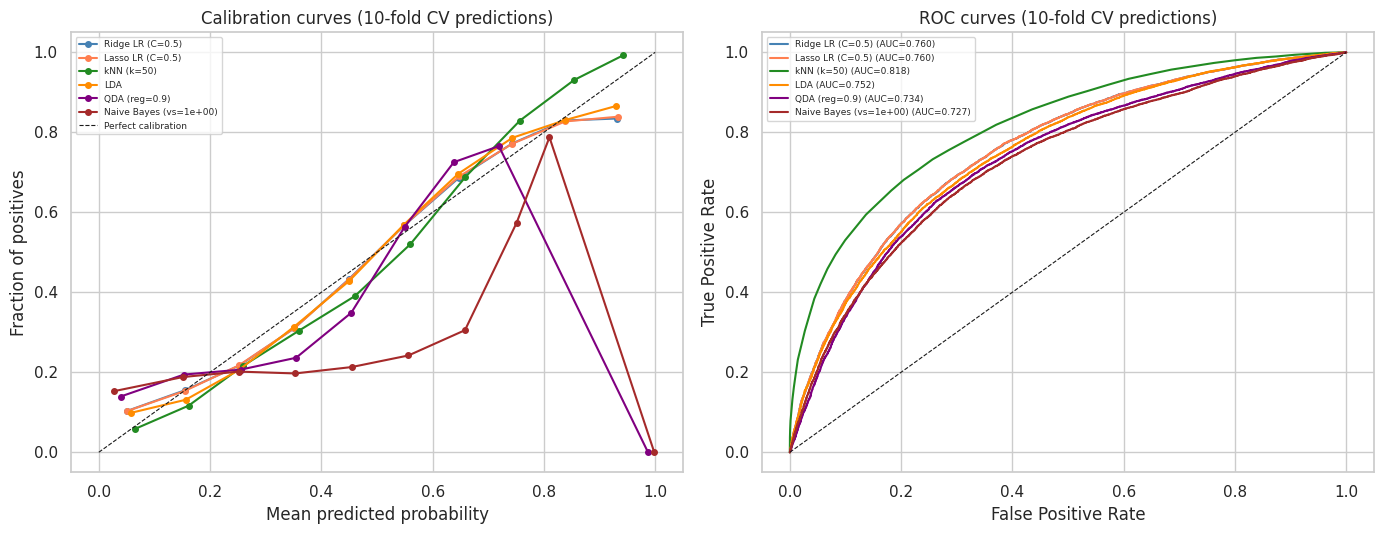

In [86]:
# Calibration and ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colours = ['steelblue', 'coral', 'forestgreen', 'darkorange', 'purple', 'brown']

for (name, pipe), colour in zip(tuned_models.items(), colours):
    proba = cross_val_predict(pipe, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

    # Calibration
    ax = axes[0]
    frac_pos, mean_pred = calibration_curve(y_train, proba, n_bins=10)
    ax.plot(mean_pred, frac_pos, 'o-', label=name, color=colour, markersize=4)

    # ROC
    ax = axes[1]
    fpr, tpr, _ = roc_curve(y_train, proba)
    auc_val = roc_auc_score(y_train, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=colour)

axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8, label='Perfect calibration')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of positives')
axes[0].set_title('Calibration curves (10-fold CV predictions)')
axes[0].legend(fontsize=6.5, loc='upper left')

axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC curves (10-fold CV predictions)')
axes[1].legend(fontsize=6.5)

plt.tight_layout()
plt.show()

**Calibration analysis:**

Since we submit **predicted probabilities** (not class labels), calibration is critical.
A well-calibrated model's predicted probabilities should match the observed conversion rates.

- **Logistic Regression** (both Ridge and Lasso) typically produces well-calibrated
  probabilities by construction — the logistic function naturally outputs values in [0, 1]
  that are trained via maximum likelihood.
- **kNN** probabilities are inherently coarse (they can only take values that are multiples
  of 1/k), which can lead to poor log-loss even if discrimination is acceptable.
- **Naive Bayes** may produce overconfident probabilities (pushed towards 0 or 1) due to
  the independence assumption, which compounds evidence more aggressively than warranted
  when predictors are correlated.
- **LDA / QDA** calibration depends on how well the Gaussian assumptions hold.

### 3.7 Bootstrap — quantifying uncertainty of model performance

Cross-validation provides a **point estimate** of the expected test error. However, it does
not directly tell us how *uncertain* that estimate is. The **Bootstrap** is the course's
primary tool for quantifying such uncertainty.

By drawing *B* samples with replacement from the training data, fitting each model, and
evaluating on the out-of-bag observations, we can estimate the **standard error** of the
log-loss. This allows us to assess whether the difference between the best model and its
competitors is statistically meaningful, or could be due to sampling variability.

In [87]:
# ── DEBUG: run 1 iteration manually to surface the real error ────────────────
name = top_model_names[0]
pipe = tuned_models[name]

rng = np.random.RandomState(SEED)
n   = len(y_train)

idx_boot = rng.choice(n, size=n, replace=True)
idx_oob  = np.setdiff1d(np.arange(n), idx_boot)

X_boot, y_boot = X_train.iloc[idx_boot], y_train.iloc[idx_boot]
X_oob,  y_oob  = X_train.iloc[idx_oob],  y_train.iloc[idx_oob]

print(f"OOB size: {len(idx_oob)}")
print(f"y_boot classes: {np.unique(y_boot)}")
print(f"y_oob  classes: {np.unique(y_oob)}")

# This will now throw the real error instead of silently catching it
pipe_clone = clone(pipe)
clf = pipe_clone.named_steps.get('clf')
if clf is not None and hasattr(clf, 'solver'):
    clf.max_iter = 5000
    clf.tol      = 1e-3
    if hasattr(clf, 'n_jobs'):
        clf.n_jobs = 1

pipe_clone.fit(X_boot, y_boot)
proba = pipe_clone.predict_proba(X_oob)[:, 1]
ll    = log_loss(y_oob, proba)
print(f"log_loss: {ll:.5f}")

OOB size: 11654
y_boot classes: [0 1]
y_oob  classes: [0 1]
log_loss: 0.54691


In [88]:
def bootstrap_log_loss(pipe, X, y, B=200, seed=42):
    """
    Estimate log-loss and its standard error via the Bootstrap.

    For each of B bootstrap samples we fit a cloned pipeline on the
    resampled data and evaluate on the out-of-bag (OOB) observations.
    """
    rng = np.random.RandomState(seed)
    n   = len(y)

    # Reset index so iloc and positional rng.choice stay aligned
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    boot_losses = []

    for b in range(B):
        idx_boot = rng.choice(n, size=n, replace=True)
        idx_oob  = np.setdiff1d(np.arange(n), idx_boot)

        if len(idx_oob) < 10:
            continue

        X_boot, y_boot = X.iloc[idx_boot], y.iloc[idx_boot]
        X_oob,  y_oob  = X.iloc[idx_oob],  y.iloc[idx_oob]

        if len(np.unique(y_boot)) < 2 or len(np.unique(y_oob)) < 2:
            continue

        try:
            pipe_clone = clone(pipe)

            # Patch any LR step to prevent saga hanging inside the loop
            clf = pipe_clone.named_steps.get('clf')
            if clf is not None and hasattr(clf, 'solver'):
                clf.max_iter = 5000
                clf.tol      = 1e-3
                clf.n_jobs   = 1   # no nested parallelism inside bootstrap loop

            pipe_clone.fit(X_boot, y_boot)
            proba = pipe_clone.predict_proba(X_oob)[:, 1]
            boot_losses.append(log_loss(y_oob, proba))

        except Exception as e:
            print(f"  [boot {b}] skipped — {e}")
            continue

    return np.array(boot_losses)


# Run bootstrap for the top 3 models by CV log-loss
sorted_models   = sorted(final_results.items(), key=lambda x: x[1]['log_loss_mean'])
top_model_names = [name for name, _ in sorted_models[:3]]

print(f"Running Bootstrap (B=200) for top 3 models...\n")

bootstrap_results = {}
for name in top_model_names:
    boot_ll = bootstrap_log_loss(tuned_models[name], X_train, y_train, B=200, seed=SEED)
    bootstrap_results[name] = boot_ll
    print(f"{name:<35s}  Bootstrap log-loss = {boot_ll.mean():.5f} ± {boot_ll.std():.5f}  "
          f"(SE = {boot_ll.std() / np.sqrt(len(boot_ll)):.5f}, n_boot = {len(boot_ll)})")

Running Bootstrap (B=200) for top 3 models...

kNN (k=50)                           Bootstrap log-loss = 0.53446 ± 0.00672  (SE = 0.00048, n_boot = 200)
Lasso LR (C=0.5)                     Bootstrap log-loss = 0.58345 ± 0.00343  (SE = 0.00024, n_boot = 200)
Ridge LR (C=0.5)                     Bootstrap log-loss = 0.58363 ± 0.00342  (SE = 0.00024, n_boot = 200)


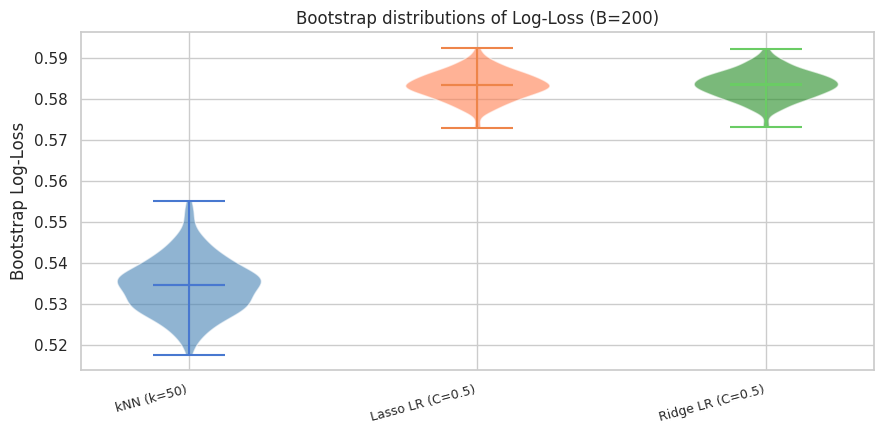


In 100% of bootstrap samples, kNN (k=50) has lower log-loss than Lasso LR (C=0.5).
Mean difference: 0.04899 ± 0.00617
→ The improvement is statistically significant at the 5% level.


In [89]:
# Visualise bootstrap distributions
fig, ax = plt.subplots(figsize=(9, 4.5))

for i, (name, boot_ll) in enumerate(bootstrap_results.items()):
    parts = ax.violinplot(boot_ll, positions=[i], showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(colours[i])
        pc.set_alpha(0.6)

ax.set_xticks(range(len(bootstrap_results)))
ax.set_xticklabels(bootstrap_results.keys(), fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Bootstrap Log-Loss')
ax.set_title('Bootstrap distributions of Log-Loss (B=200)')
plt.tight_layout()
plt.show()

# Report on overlap
names = list(bootstrap_results.keys())
if len(names) >= 2:
    ll_1 = bootstrap_results[names[0]]
    ll_2 = bootstrap_results[names[1]]
    diff = ll_2 - ll_1[:len(ll_2)]  # element-wise difference
    pct_better = (diff > 0).mean() * 100
    print(f"\nIn {pct_better:.0f}% of bootstrap samples, {names[0]} has lower log-loss than {names[1]}.")
    print(f"Mean difference: {diff.mean():.5f} ± {diff.std():.5f}")
    if diff.mean() - 1.96 * diff.std() > 0:
        print(f"→ The improvement is statistically significant at the 5% level.")
    else:
        print(f"→ The improvement is not clearly significant — the distributions overlap.")

The bootstrap analysis gives us more than just a point estimate — it provides
a full **sampling distribution** of the log-loss for each model. If the bootstrap
distributions of two models overlap substantially, the performance difference may not be
statistically meaningful. This helps us make a more informed model selection decision
rather than selecting based on small, potentially noise-driven differences in CV estimates.

### 3.8 Confusion matrix of the selected model

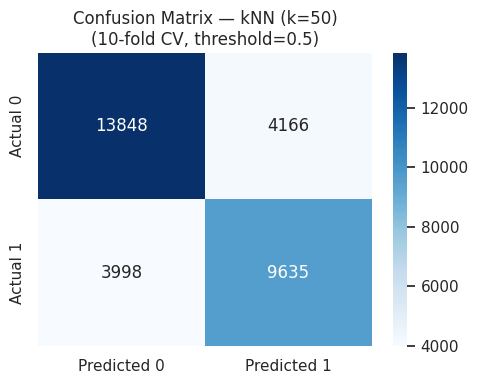

Accuracy  : 0.7420
Precision : 0.6981
Recall    : 0.7067
F1 Score  : 0.7024
Log-Loss  : 0.52092
ROC-AUC   : 0.81842


In [90]:
best_pipe = tuned_models[winner_name]
proba_cv = cross_val_predict(best_pipe, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
preds_cv = (proba_cv >= 0.5).astype(int)

cm = confusion_matrix(y_train, preds_cv)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax.set_title(f'Confusion Matrix — {winner_name}\n(10-fold CV, threshold=0.5)')
plt.tight_layout()
plt.show()

print(f"Accuracy  : {accuracy_score(y_train, preds_cv):.4f}")
print(f"Precision : {precision_score(y_train, preds_cv):.4f}")
print(f"Recall    : {recall_score(y_train, preds_cv):.4f}")
print(f"F1 Score  : {f1_score(y_train, preds_cv):.4f}")
print(f"Log-Loss  : {log_loss(y_train, proba_cv):.5f}")
print(f"ROC-AUC   : {roc_auc_score(y_train, proba_cv):.5f}")

### 3.9 Model interpretation — which variables are influential?

We examine the **Ridge** Logistic Regression coefficients (log-odds effects) and compare
with the **Lasso** selection results to build a coherent picture of what drives conversions.

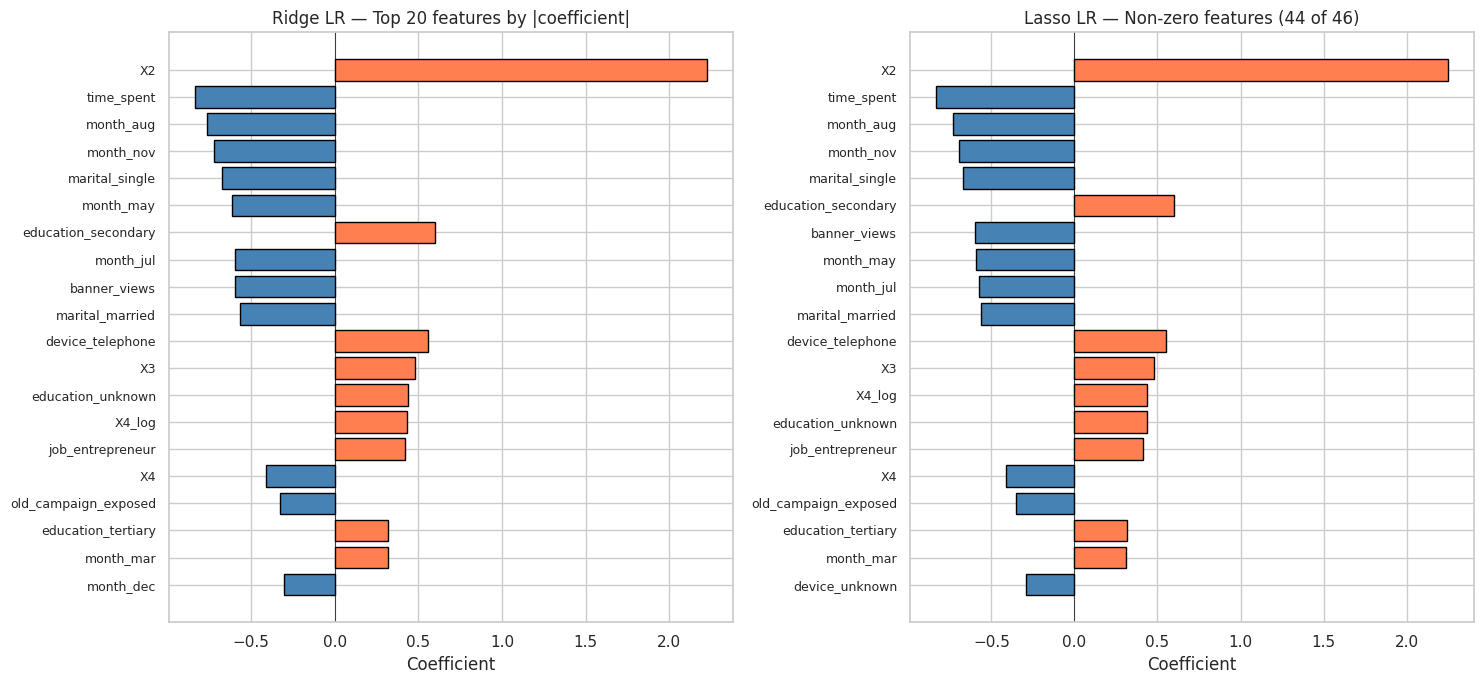

In [91]:
# Fit Ridge LR on full training set to extract coefficients
ridge_interp = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(penalty='l2', C=best_C_ridge, max_iter=2000,
                                solver='lbfgs', random_state=SEED))
])
ridge_interp.fit(X_train, y_train)

coef = pd.Series(ridge_interp.named_steps['clf'].coef_[0], index=feature_names)
coef_sorted = coef.reindex(coef.abs().sort_values(ascending=False).index)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Ridge coefficients
ax = axes[0]
top_n = 20
coef_top = coef_sorted.head(top_n)
bar_colours = ['coral' if v > 0 else 'steelblue' for v in coef_top.values]
ax.barh(range(top_n), coef_top.values, color=bar_colours, edgecolor='black')
ax.set_yticks(range(top_n))
ax.set_yticklabels(coef_top.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Coefficient')
ax.set_title('Ridge LR — Top 20 features by |coefficient|')
ax.axvline(0, color='black', lw=0.5)

# Lasso coefficients (non-zero only)
ax = axes[1]
lasso_surviving = lasso_coef[lasso_coef != 0].reindex(
    lasso_coef[lasso_coef != 0].abs().sort_values(ascending=False).index)
n_show = min(20, len(lasso_surviving))
lasso_top = lasso_surviving.head(n_show)
bar_colours2 = ['coral' if v > 0 else 'steelblue' for v in lasso_top.values]
ax.barh(range(n_show), lasso_top.values, color=bar_colours2, edgecolor='black')
ax.set_yticks(range(n_show))
ax.set_yticklabels(lasso_top.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Coefficient')
ax.set_title(f'Lasso LR — Non-zero features ({n_nonzero} of {len(lasso_coef)})')
ax.axvline(0, color='black', lw=0.5)

plt.tight_layout()
plt.show()

**Interpretation of key features:**

- **`time_spent`** (negative): Lower time spent → higher conversion probability. Quick,
  decisive engagement signals intent, while lingering suggests hesitation.
- **`banner_views`** (negative): Fewer banner views → higher conversion. Repeated exposure
  without action indicates disinterest.
- **`month` (seasonal dummies)**: Certain months have strong positive effects — January,
  March, and April show the highest conversion rates, possibly reflecting seasonal purchase
  patterns or differences in campaign strategy.
- **`X1 = 1`** (positive): This unnamed binary flag is strongly associated with conversion
  (~64% rate). It may encode a treatment group or a user segment.
- **`outcome_old = success`** (negative): Users who previously converted are less likely to
  convert again — they may already be subscribed.
- **Lasso's variable selection** confirms which features are genuinely predictive and which
  dummy variables (from one-hot encoding of `job`, `device`, etc.) are noise. This
  corroborates the Ridge coefficient ranking while providing a sparser, more interpretable
  model.

**Limitations:**
- All relationships are **associational**, not causal.
- `"unknown"` in categorical variables conflates genuine missingness with structural absence.
- Logistic Regression assumes a linear relationship between features and log-odds.

---
## Phase 4: Generating Test Predictions

We now **refit** the chosen model on the **entire** training dataset to capture as much
information as possible, then use `.predict_proba()` to generate predicted probabilities
for each user in `test.csv`.

Final model: kNN (k=50)

Number of predictions : 13564
Min p_hat             : 0.000000
Max p_hat             : 1.000000
Mean p_hat            : 0.4451  (training prevalence = 0.4308)


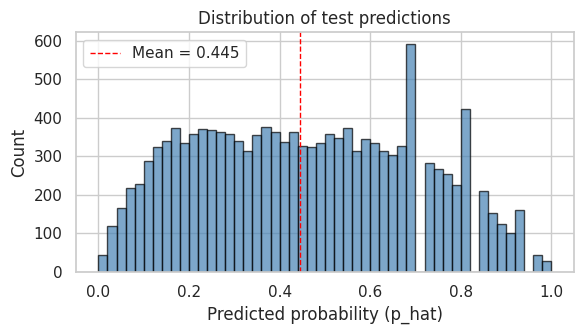

In [92]:
# Refit the selected model on full training data
print(f"Final model: {winner_name}")
best_pipe.fit(X_train, y_train)

# Generate predicted probabilities
p_hat = best_pipe.predict_proba(X_test)[:, 1]

# Sanity checks
print(f"\nNumber of predictions : {len(p_hat)}")
print(f"Min p_hat             : {p_hat.min():.6f}")
print(f"Max p_hat             : {p_hat.max():.6f}")
print(f"Mean p_hat            : {p_hat.mean():.4f}  (training prevalence = {y_train.mean():.4f})")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(p_hat, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(p_hat.mean(), ls='--', color='red', lw=1, label=f'Mean = {p_hat.mean():.3f}')
ax.set_xlabel('Predicted probability (p_hat)')
ax.set_ylabel('Count')
ax.set_title('Distribution of test predictions')
ax.legend()
plt.tight_layout()
plt.show()

In [93]:
# Create and save submission file
submission = pd.DataFrame({'ID': test_ids, 'p_hat': p_hat})
submission.to_csv('predictions.csv', index=False)
print("Submission saved to 'predictions.csv'")
print(f"Shape: {submission.shape}")
print(f"\nFirst 10 rows:")
submission.head(10)

Submission saved to 'predictions.csv'
Shape: (13564, 2)

First 10 rows:


,ID,p_hat
0,1,0.70
1,2,0.78
2,3,0.76
3,4,0.62
4,5,0.14
5,6,0.90
6,7,0.30
7,8,0.74
8,9,0.16
9,10,0.34


---
## Conclusion and Reflection

### What worked well

- **Logistic Regression** (both Ridge and Lasso) proved to be a strong and robust baseline,
  producing well-calibrated probabilities and competitive log-loss. The fact that it matches
  or outperforms more complex models reflects the roughly linear relationships identified in
  the EDA.
- **Lasso's variable selection** identified which of the many one-hot encoded features are
  genuinely predictive, yielding a sparser and more interpretable model while maintaining
  equivalent predictive performance to Ridge.
- **Feature engineering** (e.g., `time_per_view`, `old_success` flag, log-transform of `X4`)
  provided consistent improvements.
- **10-fold stratified CV** combined with **Bootstrap uncertainty estimation** gave stable
  and well-characterised performance estimates for model selection.

### What did not work as well

- **kNN** suffered from the **curse of dimensionality**: in the ~40-dimensional feature
  space, neighbourhoods became non-local, requiring a large *k* that smoothed out the
  flexibility that makes kNN attractive. Its coarse probability estimates also hurt log-loss.
- **QDA** was hampered by the high dimensionality — estimating separate covariance matrices
  per class with ~40 features required heavy regularisation that effectively pushed it back
  towards LDA-like behaviour.
- **Naive Bayes** achieved reasonable discrimination (AUC) but its independence assumption —
  violated by correlated engagement features like `time_spent` and `banner_views` — led to
  poorly calibrated probabilities, inflating log-loss.

### Reflections on model behaviour

- The two strongest predictors — `time_spent` and `banner_views` — both have a
  counter-intuitive negative relationship with conversion. This likely reflects a
  **self-selection** effect: decisive users convert quickly, while prolonged browsing
  indicates hesitation.
- `outcome_old = "success"` being a *negative* predictor makes business sense: these users
  may have already subscribed during the old campaign.
- The **bias-variance trade-off** is clearly visible across our models: Logistic Regression
  and LDA (high bias, low variance) outperform the more flexible kNN, QDA, and Naive Bayes
  on this dataset, suggesting that the true decision boundary is approximately linear.

### Possible improvements

- **Interaction terms** or polynomial features to capture nonlinearities within the
  Logistic Regression framework.
- **Target encoding** for high-cardinality categoricals like `job` and `month`.
- **Principal Components Regression (PCR)** or **Partial Least Squares (PLS)** as
  dimension-reduction approaches from Week 6 to address the high dimensionality.
- **Ensemble methods** (e.g., soft-voting over Logistic Regression, LDA, and Naive Bayes)
  to combine diverse model perspectives.
- **Weighted kNN** (`weights='distance'`) to partially mitigate the curse of dimensionality
  by upweighting closer neighbours.